In [1]:
import pandas as pd
from deeplogger.filters import *
from deeplogger.image_processing import *
from deeplogger.importLASv3 import *
from deeplogger.labels import *
import os

path_to_data = r"C:\Users\StartKlar\Documents\Msc_Thesis\Data\New_datasets_HS\CB1\\"
files = os.listdir(path_to_data)
print(files)


['CB1_ATV_20200513.las', 'CB1_ATV_centralized_20191010.las', 'CB1_OTV_20191010.las', 'CB1_OTV_ATV_Structure_Interp.csv', 'CB1_OTV_ATV_Structure_Interp.xlsx']


In [2]:
file_name = file_atv_am = files[2]
#file_name_OTV = files[4]
#depth_correction = 0.23 # for MB1
#depth_correction =0.23 # for MB3
#depth_correction = 0.33 # for MB5 034
#depth_correction = 0.00 # for OTV ST1
depth_correction = 0.00 #for ATV ST1
#get the depth to see how many snippets can be created (i)
first_dataline = get_first_data_linenumber(file_name, path_to_data)
file_in = pd.read_csv(path_to_data+ file_name, skiprows=first_dataline, header=None)
depth = file_in[0].to_numpy(dtype='float') + depth_correction

depth_resolution = (max(depth)-min(depth))/len(depth)
depth_subset =depth[(depth >= 139.7) & (depth <= 140.2)]

print(depth_resolution)


0.0019791483463002368


In [3]:
from skimage.transform import rescale, resize, downscale_local_mean
depth_correction = 0.00
data_subset, index = get_data_subset_from_depth_range(
        file_name=file_name,
        data_path=path_to_data,
        data_type='otv',
        #depth_range=[61-(0.7105/2) , 61+ (0.7105/2) ] for MB3
        depth_range = [139.7, 140.2])
depth_subset = depth_subset + depth_correction
# Create a new data_subset with alternate elements
azimuth_values = len(data_subset[0])
# for each depth, we have 720 azimuthal values
# we want to create a new data_subset with alternate azimuthal values, by keeping in mind that this is RGB data
# so we have 3 values for each azimuthal value
# we want to keep each value for each azimuthal value, so we will have 360 azimuthal values
#we will keep the first trio of RGB, then the third, then the fifth, etc.
#we will have 360 azimuthal values
 
print(data_subset.shape)

C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\interna

(254, 900, 3)


In [4]:
# Resize the transformed data
resized_data_subset = resize(data_subset, (data_subset.shape[0], data_subset.shape[1]//2.5),
                                   anti_aliasing=True)
data_subset = replace_empty_measurements(resized_data_subset, 0.0)

In [5]:
print(data_subset.shape)


(254, 360, 3)


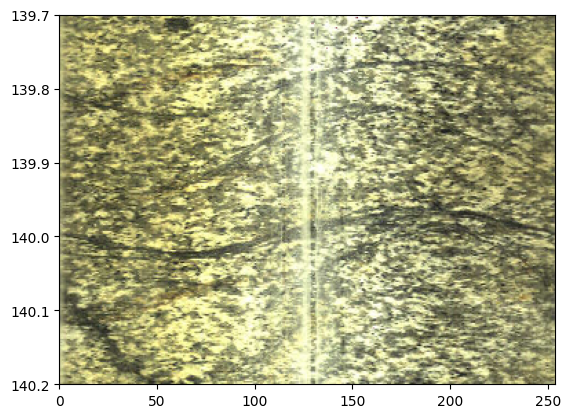

In [6]:
 
plt.imshow(data_subset, aspect='auto', extent=[0, len(data_subset), max(depth_subset), min(depth_subset)])
depth_resolution = (max(depth_subset)-min(depth_subset))/len(depth_subset)


In [7]:
#excel_file = r"C:\Users\StartKlar\Documents\Msc_Thesis\Data\Exportation_interpreted_structures\Merged_File_Structures.xlsx"
excel_file = r"C:\Users\StartKlar\Documents\Msc_Thesis\Data\New_datasets_HS\CB1\CB1_OTV_ATV_Structure_Interp.xlsx"

# Define the columns you want to load
#columns = ["borehole", "Depth (m)", "Azimuth (deg)", "Dip (deg)", "Aperture (mm)", "Bedretto_Structure"]
columns = ["Depth", "Azimuth", "Dip", "Aperture", "Bedretto_Structure"]
# Load the DataFrame from Excel file with specified columns
label_df = pd.read_excel(excel_file, usecols=columns)

# only select the labels from sour borehole of interest
#label_df = label_df[label_df["borehole"] == "ST1"]


print(len(label_df))

639


In [8]:

def filter_labels_from_range(label_df: pd.DataFrame,
                             filter_type: str,
                             filter_range: (list, tuple)):
    '''Filter the label dataframe based on entries of individual columns that have numeric values (e.g., depth and aperture).
    The dataframe returned has only the filtered values between the desired range.
    Args:
        label_df: label dataframe
        filter_type: column name of the dataframe to filter
        filter_range: range of values to filter
    Returns:
        label_df: filtered label dataframe

        '''
    # check if filter type exists in dataframe columns, otherwise return empty dataframe
    if filter_type not in label_df.columns:
        print('Filter type does not exist in dataframe columns')
        return pd.DataFrame()
    # check if filter range is a list or tuple with two entries, otherwise return empty dataframe
    if not isinstance(filter_range, (list, tuple)) or len(filter_range) != 2:
        print('Filter range must be a list or tuple with two entries')
        return pd.DataFrame()
    # filter based on filter type and range
    return label_df[(label_df[filter_type] >= filter_range[0]) & (label_df[filter_type] <= filter_range[1])].copy()

In [9]:

    assigned_labels = []
 # Calculate the minimum and maximum depth values for the current snippet
    min_depth = min(depth_subset) - depth_correction
    max_depth = max(depth_subset) + depth_correction
    
    # Filter labels based on depth range for the current snippet
    filtered_label_df = filter_labels_from_range(label_df, 'Depth', (min_depth, max_depth))
# Append the assigned labels to the list
    assigned_labels.append(filtered_label_df)

# Concatenate all assigned labels into a single DataFrame
assigned_labels_df = pd.concat(assigned_labels, ignore_index=True)
print(assigned_labels_df)

    Depth  Azimuth    Dip  Aperture Bedretto_Structure
0  139.80    72.72  35.75       0.0     Bt-rich filled
1  139.88    60.79  45.00       0.0     Bt-rich filled
2  139.99    82.25  30.96       0.0     Bt-rich filled
3  140.10    92.98  64.54       0.0     Bt-rich filled


In [10]:
# First, we extract the information of the labels as following : 
azimuths = []
dips = []
depths = []
apertures = []

# Define depth interval
min_depth = min(depth_subset)
max_depth = max(depth_subset)

# Iterate through each row in the DataFrame
for index, label in assigned_labels_df.iterrows():
    # Check if depth is within the specified interval
    if min_depth <= label['Depth'] <= max_depth:
        # Extract label information
        azimuth = label['Azimuth']
        dip = label['Dip'] 
        depth = label['Depth']
        aperture = label['Aperture']

        # Replace aperture value with 2 if it's 0
        if aperture == 0:
            aperture = 6

        # Append values to respective lists
        azimuths.append(azimuth)
        dips.append(dip)
        depths.append(depth)
        apertures.append(aperture)
print(azimuths)
# Now, azimuth_values, dip_values, depth_values, and aperture_values
# contain all the respective values within the specified depth interval.


[72.72, 60.79, 82.25, 92.98]


In [11]:
def crop_depth(Z_up, Z_down, depth):
    """Crop the depth of the picks to the depth of the borehole.
    Args:
        Z_up: depth of the top of the pick
        Z_down: depth of the/9 bottom of the pick
        depth: depth vector of the borehole
    Returns:
        Z_up: depth of the top of the pick cropped to the depth of the borehole
        Z_down: depth of the bottom of the pick cropped to the depth of the borehole
    """
    max_depth = max(depth)
    min_depth = min(depth)
    Z_up[Z_up > max_depth] = max_depth
    Z_down[Z_down > max_depth] = max_depth
    Z_up[Z_up < min_depth] = min_depth
    Z_down[Z_down < min_depth] = min_depth

    # Ensure that cropped depths are within the bounds of the depth vector
    Z_up[Z_up < depth[0]] = depth[0]
    Z_down[Z_down > depth[-1]] = depth[-1]

    return Z_up, Z_down


def get_label(azimuth: float,
              azimuth_correction: float,
              dip: float,
              dip_correction: float,
              depth: float,
              aperture: float,
              depth_vector: np.array,
              bh_diameter: float,
              azimuth_values: int = 360):
    """Get a label for a pick in the form of a rasterized image.
    Args:
        azimuth: azimuth of the pick in degrees
        dip: dip of the pick in degrees
        depth: mean depth of the pick
        aperture: aperture of the pick in mm
        depth_vector: depth vector of the borehole
        bh_diameter: borehole diameter in meters
        azimuth_values: number of azimuth values to use for the pick
    Returns:
        im: rasterized image of the pick
        """
    # convert aperture to meters
    aperture = aperture / 1000
    # if mean depth is outside the depth vector, then the pick is not valid
    azimuth_radians = np.linspace(0, 2 * np.pi, azimuth_values)
    azimuth_range = range(azimuth_values)
    #amplitude = depth + np.sin(azimuth_radians + np.deg2rad(azimuth + azimuth_correction)) * (np.tan(np.deg2rad(dip +  dip_correction))) * (bh_diameter/2)

    amplitude = depth + np.cos(azimuth_radians + np.deg2rad(azimuth + azimuth_correction)) * (1/(np.cos(np.deg2rad(dip + dip_correction)))) * (bh_diameter/2)
    Z_up = amplitude + aperture 
    Z_down = amplitude - aperture 
    Z_up, Z_down = crop_depth(Z_up, Z_down, depth_vector)
    im = np.zeros((depth_vector.shape[0], azimuth_values))
    if np.array(Z_up == Z_down).all():
        im[np.digitize(Z_up, depth_vector), azimuth_range] = 1
    else:
        Z_up_M = np.tile(Z_up, (depth_vector.shape[0], 1))
        Z_down_M = np.tile(Z_down, (depth_vector.shape[0], 1))
        Z_M = np.tile(depth_vector, (azimuth_values, 1)).T
        im[np.logical_and(Z_M < Z_up_M, Z_M > Z_down_M)] = 1
        
    
    return im, Z_up, Z_down

In [12]:

bh_diameter = 0.097
dip_correction = 0.00
azimuth_correction = 0.00
 
min_depth = min(depth_subset)
max_depth = max(depth_subset)

# Initialize an empty image
image = np.zeros((360, azimuth_values))

for i in range(len(depths)):
    label_depth = depths[i]
    aperture_value = apertures[i]
    azimuth = azimuths[i]
    dip = dips[i]
        # Create depth vector using snippet's depth
    depth_vector = np.linspace(min(depth_subset), max(depth_subset), 360)  # Adjust to 360 elements
    
        # Generate label image using get_label function
    label_image, Z_Up, Z_Down = get_label(azimuth=azimuth, azimuth_correction=azimuth_correction, 
                                dip=dip, dip_correction=dip_correction, depth=label_depth, 
                                aperture=aperture_value, depth_vector=depth_vector, 
                                bh_diameter=bh_diameter, azimuth_values=azimuth_values)
    
        # Add label image to the snippet's image
    image += label_image
# invert image along x axis
image = np.flip(image, axis=1)

# Ensure the image has the right dimensions
assert image.shape == (360, azimuth_values)

print(image)
print(max(Z_Up))
print(min(Z_Down))


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
140.2
139.98117830688676


In [13]:
def dnorm(x, mu, sd):
    return 1 / (np.sqrt(2 * np.pi) * sd) * np.e ** (-np.power((x - mu) / sd, 2) / 2)

def gaussian_kernel(size, sigma=1):
    kernel_1D = np.linspace(-(size // 2), size // 2, size)
    for i in range(size):
        kernel_1D[i] = dnorm(kernel_1D[i], 0, sigma)
    kernel_2D = np.outer(kernel_1D.T, kernel_1D.T)
    kernel_2D *= 1.0 / kernel_2D.max()
    return kernel_2D


def convolution(image, kernel, average=False):
    image_row, image_col = image.shape
    kernel_row, kernel_col = kernel.shape

    output = np.zeros(image.shape)

    pad_height = int((kernel_row - 1) / 2)
    pad_width = int((kernel_col - 1) / 2)

    padded_image = np.zeros((image_row + (2 * pad_height), image_col + (2 * pad_width)))

    padded_image[pad_height:padded_image.shape[0] - pad_height,
    pad_width:padded_image.shape[1] - pad_width] = image

    for row in range(image_row):
        for col in range(image_col):
            output[row, col] = np.sum(kernel * padded_image[row:row + kernel_row, col:col + kernel_col])
            if average:
                output[row, col] /= kernel.shape[0] * kernel.shape[1]
    return output


def gaussian_blur(image, kernel_size):
    kernel = gaussian_kernel(kernel_size, sigma=np.sqrt(kernel_size))
    conv = convolution(image, kernel, average=False)
    return conv/conv.max()


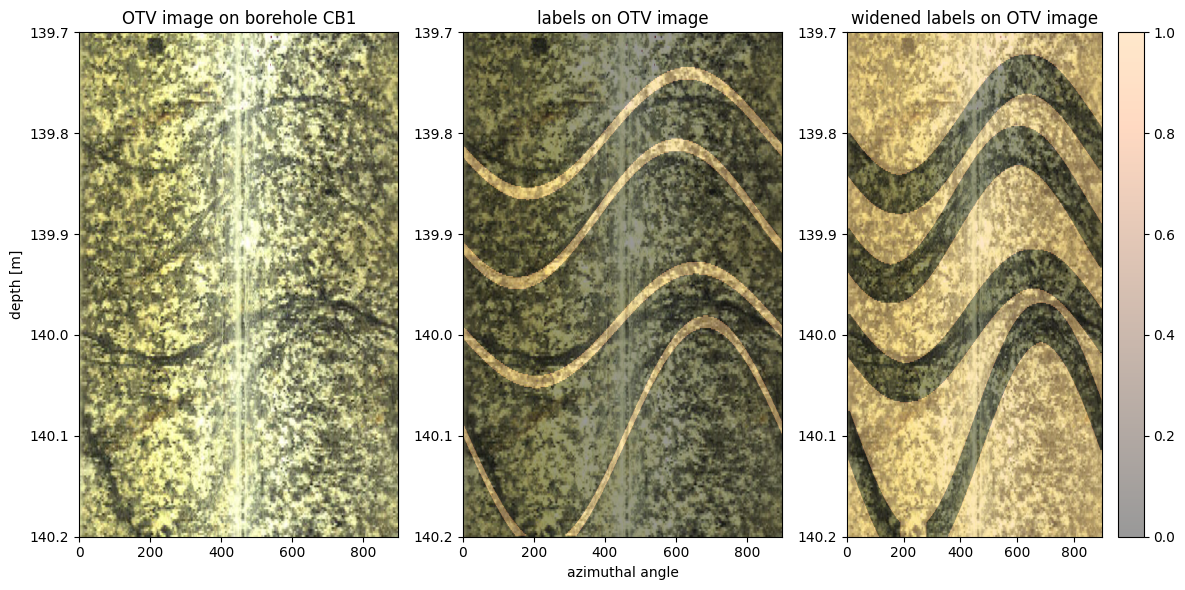

In [16]:
borehole_name = 'CB1'
label_widened= neighbor_filter(image, kernel_size=20)
inverted_label = invert_label_values(label_widened)
# now we plot the image to vizualise the resuult : 
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

# Plot the first image in the first subplot
axs[0].imshow(data_subset, aspect='auto', extent=[0, azimuth_values, max_depth,min_depth])
axs[0].set_ylabel("depth [m]")
axs[0].set_title(f"OTV image on borehole {borehole_name}")

# Plot the first image in the first subplot
axs[1].imshow(data_subset, aspect='auto', extent=[0, azimuth_values, max_depth, min_depth])
axs[1].imshow(image, cmap='copper', aspect='auto', alpha=0.4, extent=[0, azimuth_values, max_depth, min_depth])
axs[1].set_xlabel(f"azimuthal angle")
axs[1].set_title(f"labels on OTV image")


# Plot the second image in the second subplot
axs[2].imshow(data_subset, aspect='auto', extent=[0, azimuth_values, max_depth, min_depth])
im =axs[2].imshow(inverted_label, cmap='copper', aspect='auto', alpha=0.4, extent=[0, azimuth_values, max_depth, min_depth])
axs[2].set_title(f"widened labels on OTV image")

cbar = plt.colorbar(im, ax=axs[2])

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()
